# Análisis Histórico de Acciones de Netflix (NFLX)

Este proyecto tiene como objetivo analizar el comportamiento histórico de las acciones de Netflix (NFLX) utilizando técnicas de análisis exploratorio de datos (EDA), visualización, análisis temporal y modelos predictivos básicos.

* Objetivo:
Analizar el comportamiento histórico de las acciones de Netflix e identificar patrones, tendencias y posibles predicciones futuras.

## Importar Librerias

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


## Carga de datos

In [85]:
# Carga del Dataset
df = pd.read_csv("../data/NFLX_stocks.csv")
# Verificacion de datos
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5803 entries, 0 to 5802
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       5802 non-null   object
 1   open       5803 non-null   object
 2   high       5803 non-null   object
 3   low        5803 non-null   object
 4   close      5803 non-null   object
 5   adj_close  5803 non-null   object
 6   volume     5803 non-null   object
dtypes: object(7)
memory usage: 317.5+ KB


In [86]:
df.head()

,date,open,high,low,close,adj_close,volume
0,NaN,NFLX,NFLX,NFLX,NFLX,NFLX,NFLX
1,2002-05-23,1.1564290523529053,1.2428569793701172,1.1457140445709229,1.1964290142059326,1.1964290142059326,104790000
2,2002-05-24,1.214285969734192,1.225000023841858,1.1971429586410522,1.2100000381469727,1.2100000381469727,11104800
3,2002-05-28,1.2135709524154663,1.2321430444717407,1.157142996788025,1.157142996788025,1.157142996788025,6609400
4,2002-05-29,1.1642860174179077,1.1642860174179077,1.0857139825820923,1.1035710573196411,1.1035710573196411,6757800


## Limpieza de datos

In [87]:
# Eliminar la primera fila incorrecta

df = df.iloc[1:].copy()

# Convertir fecha

df['date'] = pd.to_datetime(df['date'])

# Convertir columnas numéricas
numeric_cols = ['open', 'high', 'low', 'close', 'adj_close', 'volume']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5802 entries, 1 to 5802
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       5802 non-null   datetime64[ns]
 1   open       5802 non-null   float64       
 2   high       5802 non-null   float64       
 3   low        5802 non-null   float64       
 4   close      5802 non-null   float64       
 5   adj_close  5802 non-null   float64       
 6   volume     5802 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 317.4 KB


In [88]:
df.head()

,date,open,high,low,close,adj_close,volume
1,2002-05-23,1.156429,1.242857,1.145714,1.196429,1.196429,104790000
2,2002-05-24,1.214286,1.225000,1.197143,1.210000,1.210000,11104800
3,2002-05-28,1.213571,1.232143,1.157143,1.157143,1.157143,6609400
4,2002-05-29,1.164286,1.164286,1.085714,1.103571,1.103571,6757800
5,2002-05-30,1.107857,1.107857,1.071429,1.071429,1.071429,10154200


In [89]:
df.isnull().sum()

date         0
open         0
high         0
low          0
close        0
adj_close    0
volume       0
dtype: int64

## Analisis Exploratorio

In [90]:
df.describe()

,date,open,high,low,close,adj_close,volume
count,5802,5802.000000,5802.000000,5802.000000,5802.000000,5802.000000,5.802000e+03
mean,2013-11-29 19:26:29.658738176,172.720291,175.297992,170.150462,172.807773,172.807773,1.515328e+07
min,2002-05-23 00:00:00,0.377857,0.410714,0.346429,0.372857,0.372857,2.856000e+05
25%,2008-02-27 06:00:00,4.308928,4.401786,4.225714,4.307143,4.307143,5.391400e+06
50%,2013-11-28 00:00:00,47.290001,47.903570,46.326427,47.187143,47.187143,9.374850e+06
75%,2019-09-04 18:00:00,318.120003,323.845001,312.787491,317.935005,317.935005,1.804652e+07
max,2025-06-12 00:00:00,1259.410034,1262.810059,1237.290039,1250.520020,1250.520020,3.234140e+08
std,NaN,234.674992,237.933952,231.550122,234.885388,234.885388,1.837246e+07


### Evaluación del precio

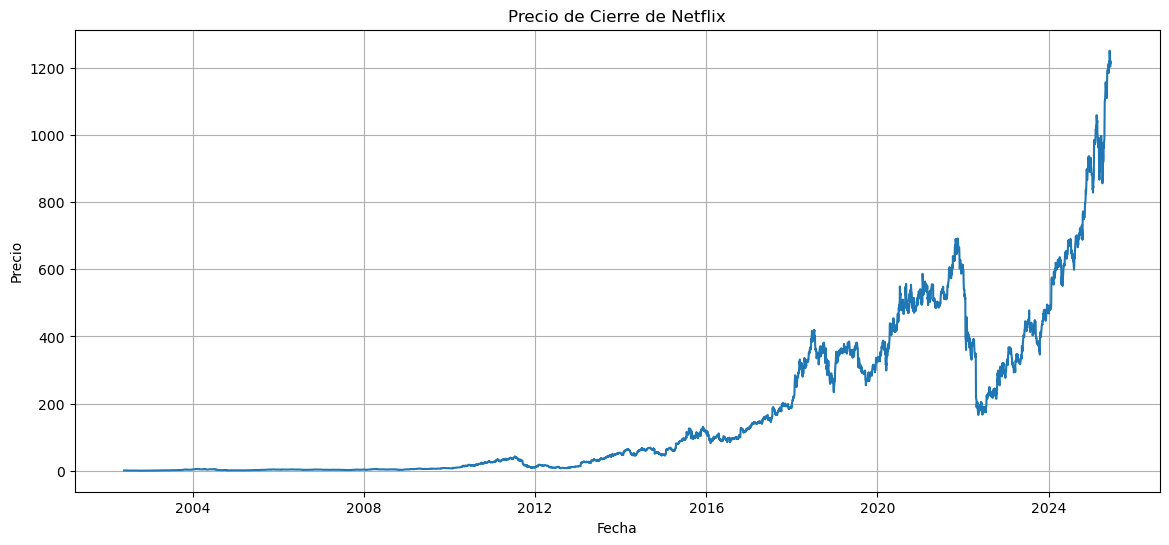

In [91]:
plt.figure(figsize=(14,6))
plt.plot(df['date'], df['close'])
plt.title('Precio de Cierre de Netflix')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.grid(True)
plt.show()

### Volumen de operaciones

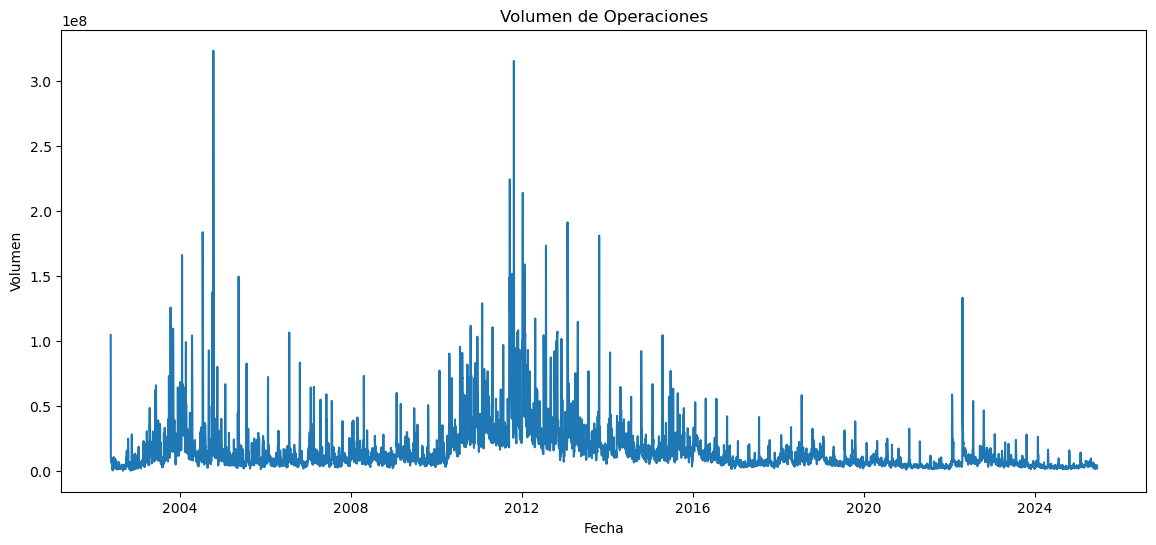

In [92]:
plt.figure(figsize=(14,6))
plt.plot(df['date'], df['volume'])
plt.title('Volumen de Operaciones')
plt.xlabel('Fecha')
plt.ylabel('Volumen')
plt.show()

### Distribución de precio de cierre

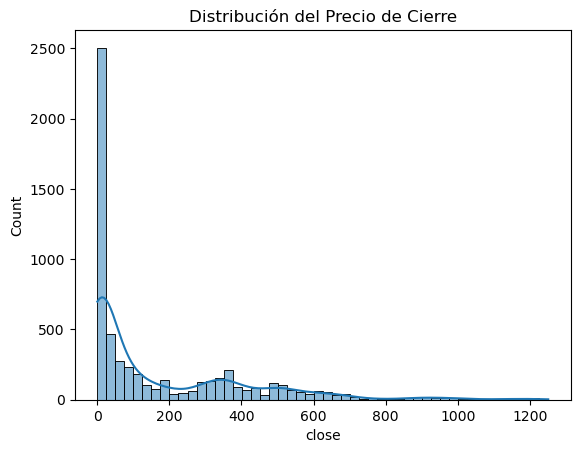

In [93]:
sns.histplot(df['close'], bins=50, kde=True)
plt.title('Distribución del Precio de Cierre')
plt.show()

## Indicadores financieros

In [94]:
# Calculo de media móvil de 30 días
df['MA30'] = df['close'].rolling(window=30).mean()

In [95]:
# Calculo de media móvil de 100 días
df['MA100'] = df['close'].rolling(window=100).mean()

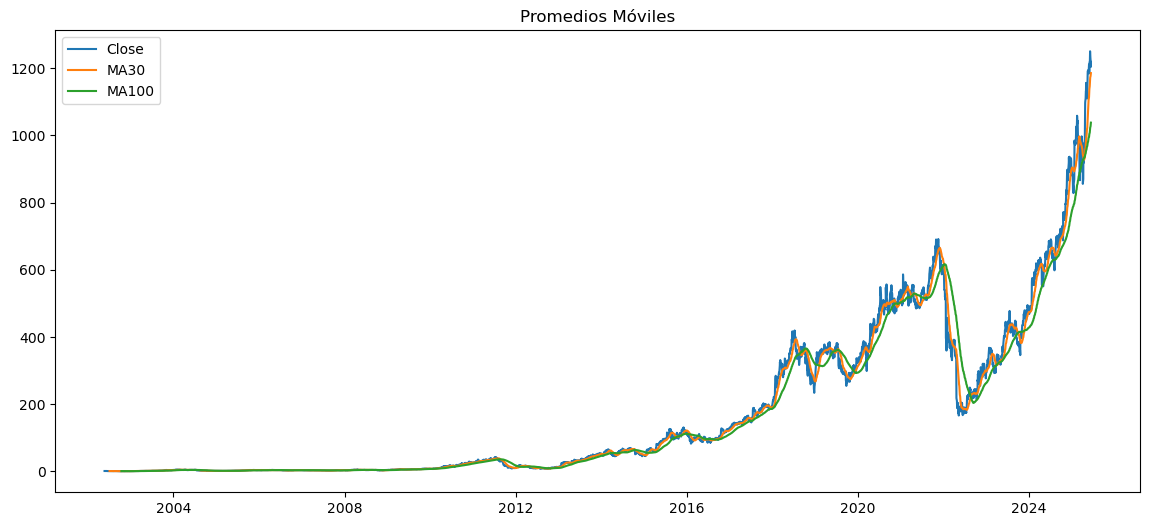

In [96]:
# Grafica de visualización
plt.figure(figsize=(14,6))
plt.plot(df['date'], df['close'], label='Close')
plt.plot(df['date'], df['MA30'], label='MA30')
plt.plot(df['date'], df['MA100'], label='MA100')

plt.legend()
plt.title('Promedios Móviles')
plt.show()

## Análisis de volatibilidad

In [97]:
# Calculo del rendimiento diario
df['daily_return'] = df['close'].pct_change()

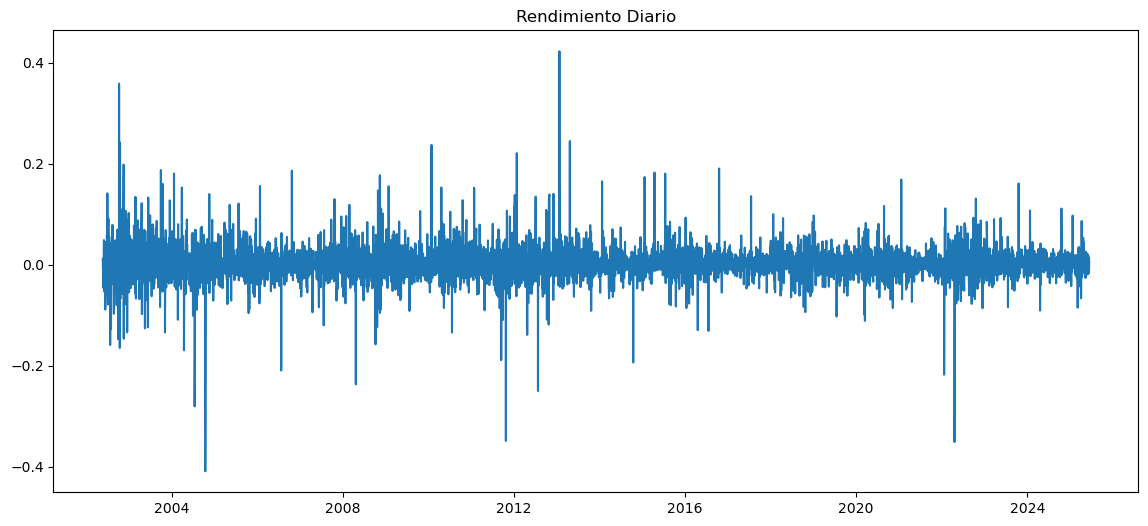

In [98]:
# Visualización
plt.figure(figsize=(14,6))
plt.plot(df['date'], df['daily_return'])
plt.title('Rendimiento Diario')
plt.show()

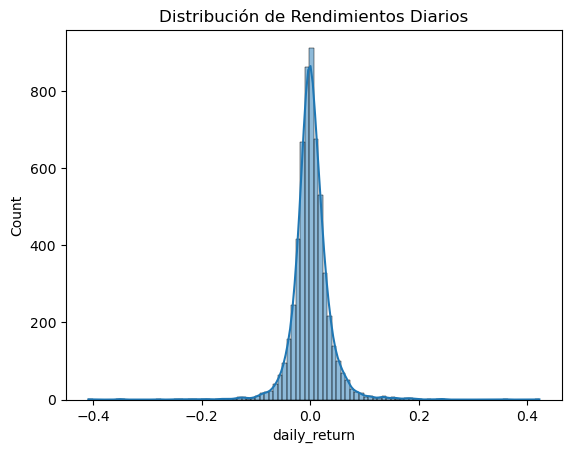

In [99]:
# Distribucion de rendimiento
sns.histplot(df['daily_return'].dropna(), bins=100, kde=True)
plt.title('Distribución de Rendimientos Diarios')
plt.show()

## Modelo Regresión lineal

### Preparación de datos

In [100]:
# Variables
X = df[['open', 'high', 'low', 'volume']]
y = df['close']

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Entrenamiento del modelo

In [101]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Predicciones

In [102]:
y_pred = model.predict(X_test)

### Evaluaciones

In [103]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print('MAE:', mae)
print('RMSE:', rmse)

MAE: 1.143535739258035
RMSE: 2.5212481170884984


### Visualización

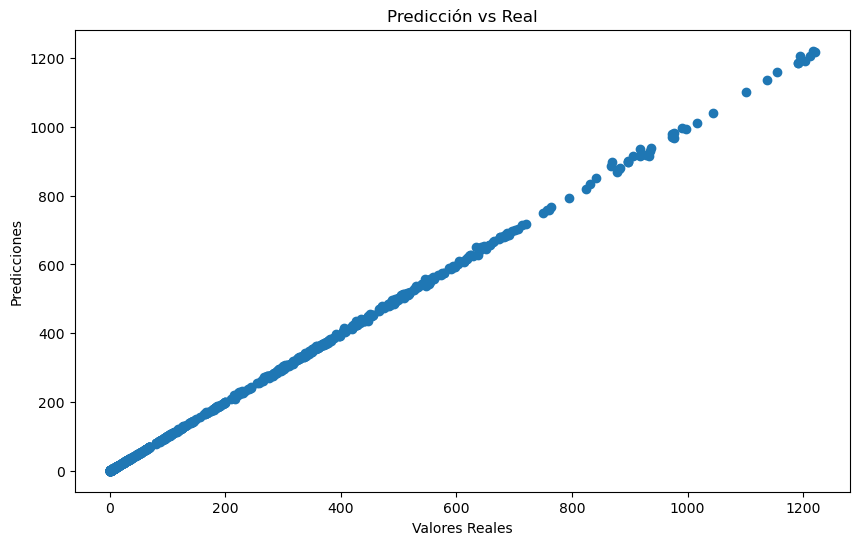

In [104]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicción vs Real')
plt.show()

## Modelos Predictivos Avanzados

In [130]:
# Preparación de datos
# Ordenar por fecha
df = df.sort_values('date')

# Variables temporales
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

# Rendimiento diario
df['return'] = df['close'].pct_change()

# Medias móviles
df['MA7'] = df['close'].rolling(7).mean()
df['MA30'] = df['close'].rolling(30).mean()

# Volatilidad
df['volatility'] = df['return'].rolling(7).std()

# Precio de cierre del siguiente día
df['target'] = df['close'].shift(-1)

# Eliminar valores nulos
df = df.dropna()

# Visualizar
df.head()

,date,open,high,low,close,adj_close,volume,MA30,MA100,daily_return,year,month,day,return,MA7,volatility,target
129,2002-11-22,0.757143,0.800000,0.752143,0.786429,0.786429,4492600,0.636310,0.802279,0.000910,2002,11,22,0.000910,0.714388,0.109249,0.792857
130,2002-11-25,0.792857,0.796429,0.753571,0.792857,0.792857,4771200,0.644929,0.797443,0.008174,2002,11,25,0.008174,0.739286,0.105753,0.749286
131,2002-11-26,0.771429,0.785714,0.748571,0.749286,0.749286,1771000,0.651571,0.793179,-0.054954,2002,11,26,-0.054954,0.753469,0.111496,0.751429
132,2002-11-27,0.761429,0.765714,0.743571,0.751429,0.751429,1069600,0.661310,0.789086,0.002860,2002,11,27,0.002860,0.749592,0.081737,0.775000
133,2002-11-29,0.750000,0.795000,0.742857,0.775000,0.775000,932400,0.668810,0.785200,0.031368,2002,11,29,0.031368,0.765408,0.051207,0.761429


### Random Forest

In [131]:

features = [
    'open',
    'high',
    'low',
    'volume',
    'MA7',
    'MA30',
    'volatility'
]

X = df[features]

y = df['target']

df = df.dropna()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

Random Forest
MAE: 95.94643964200421
RMSE: 182.38084592670424


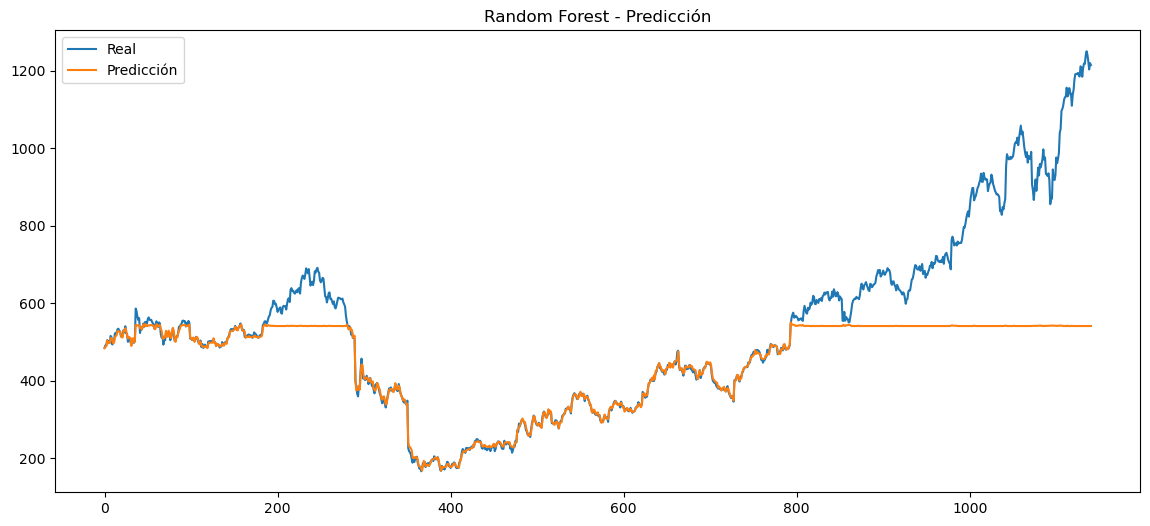

In [107]:
# Visualización
plt.figure(figsize=(14,6))

plt.plot(y_test.values, label='Real')
plt.plot(y_pred_rf, label='Predicción')

plt.title('Random Forest - Predicción')
plt.legend()
plt.show()

### XGBoost

In [108]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)

XGBoost
MAE: 92.27549652714775
RMSE: 181.75768266952957


In [109]:
# Importancia de las variables
importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

      Feature  Importance
2         low    0.594873
1        high    0.262132
0        open    0.128227
4         MA7    0.009893
5        MA30    0.004800
6  volatility    0.000042
3      volume    0.000034


### LSTM

In [110]:
# Preparar datos
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['close']])

In [111]:
# Crear secuencias
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

In [116]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    Input
)

model = Sequential()
model.add(Input(shape=(X.shape[1], 1)))
model.add(LSTM(
    64,
    return_sequences=True
))

model.add(Dropout(0.2))
model.add(LSTM(64))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

In [113]:
# Entrenamiento
history = model.fit(
    X,
    y,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 24s 102ms/step - loss: 8.9897e-04 - val_loss: 6.8070e-04
Epoch 2/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 16s 115ms/step - loss: 1.8524e-04 - val_loss: 9.6118e-04
Epoch 3/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 22s 151ms/step - loss: 1.5766e-04 - val_loss: 0.0012
Epoch 4/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 33s 89ms/step - loss: 1.5092e-04 - val_loss: 6.5646e-04
Epoch 5/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 23s 107ms/step - loss: 1.4012e-04 - val_loss: 0.0025
Epoch 6/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 15s 103ms/step - loss: 1.4857e-04 - val_loss: 6.4009e-04
Epoch 7/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 13s 93ms/step - loss: 1.3766e-04 - val_loss: 5.4064e-04
Epoch 8/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 17s 116ms/step - loss: 1.2644e-04 - val_loss: 6.1368e-04
Epoch 9/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 18s 99ms/step - loss: 1.1401e-04 - val_loss: 0.0028
Epoch 10/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 18s 83ms/step - loss: 1.2467e-04 - val_loss: 5.6756e-04
Epoch 11/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 11s 

In [119]:
y_pred_lstm = model.predict(X)
y_pred_lstm = scaler.inverse_transform(y_pred_lstm)
y_real_lstm = scaler.inverse_transform(y)

177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step


In [120]:
mae_lstm = mean_absolute_error(
    y_real_lstm,
    y_pred_lstm
)

rmse_lstm = np.sqrt(
    mean_squared_error(
        y_real_lstm,
        y_pred_lstm
    )
)

print("LSTM MAE:", mae_lstm)
print("LSTM RMSE:", rmse_lstm)

LSTM MAE: 142.431241608492
LSTM RMSE: 238.33554603440797


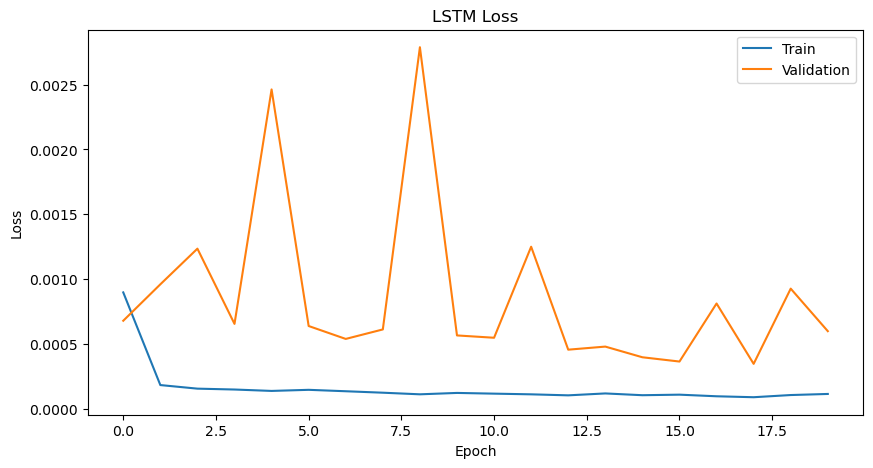

In [121]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

## Comparativa de modelos

In [125]:
results = pd.DataFrame({
    'Modelo': [
        'Linear Regression',
        'Random Forest',
        'XGBoost',
        'LSTM'
    ],
    
    'MAE': [
        mae,
        mae_rf,
        mae_xgb,
        mae_lstm
    ],
    
    'RMSE': [
        rmse,
        rmse_rf,
        rmse_xgb,
        rmse_lstm
    ]
} )

results = results.sort_values(
    by='RMSE',
    ascending=True
)
results

,Modelo,MAE,RMSE
0,Linear Regression,1.143536,2.521248
1,Random Forest,85.219014,175.194836
2,XGBoost,92.275497,181.757683
3,LSTM,142.431242,238.335546


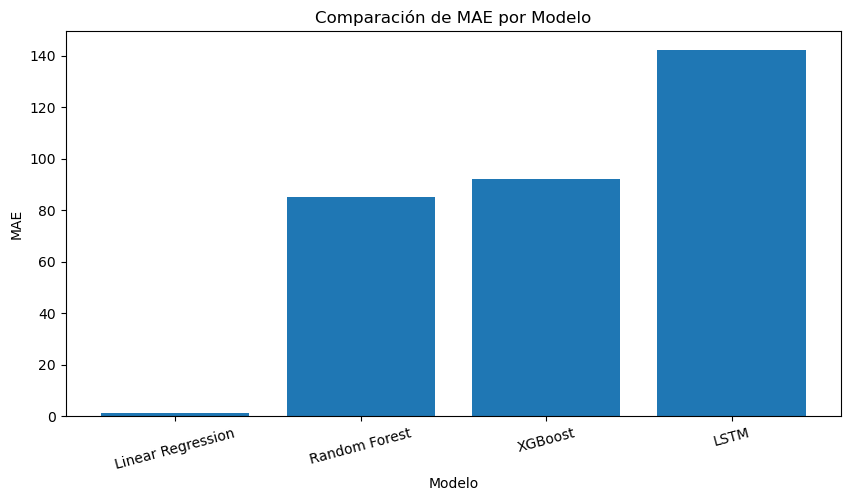

In [126]:
# Comparacion MAE
plt.figure(figsize=(10,5))

plt.bar(results['Modelo'], results['MAE'])

plt.title('Comparación de MAE por Modelo')
plt.xlabel('Modelo')
plt.ylabel('MAE')

plt.xticks(rotation=15)

plt.show()

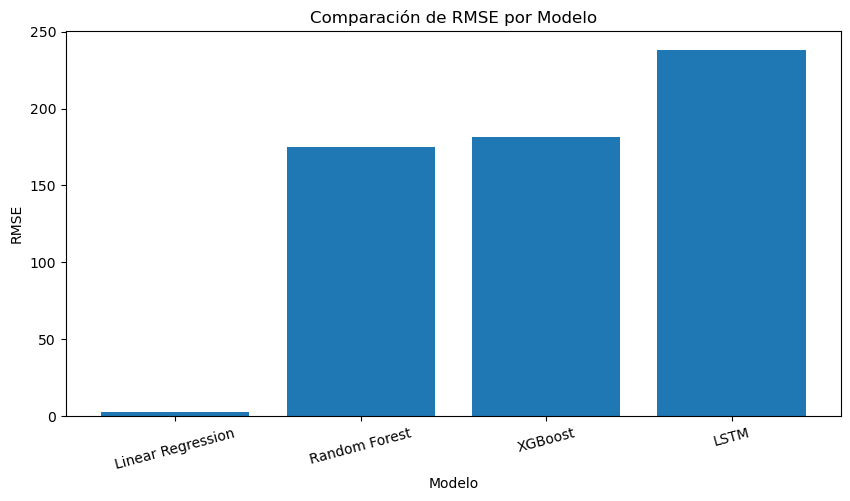

In [127]:
# Comparacion RMSE
plt.figure(figsize=(10,5))

plt.bar(results['Modelo'], results['RMSE'])

plt.title('Comparación de RMSE por Modelo')
plt.xlabel('Modelo')
plt.ylabel('RMSE')

plt.xticks(rotation=15)

plt.show()

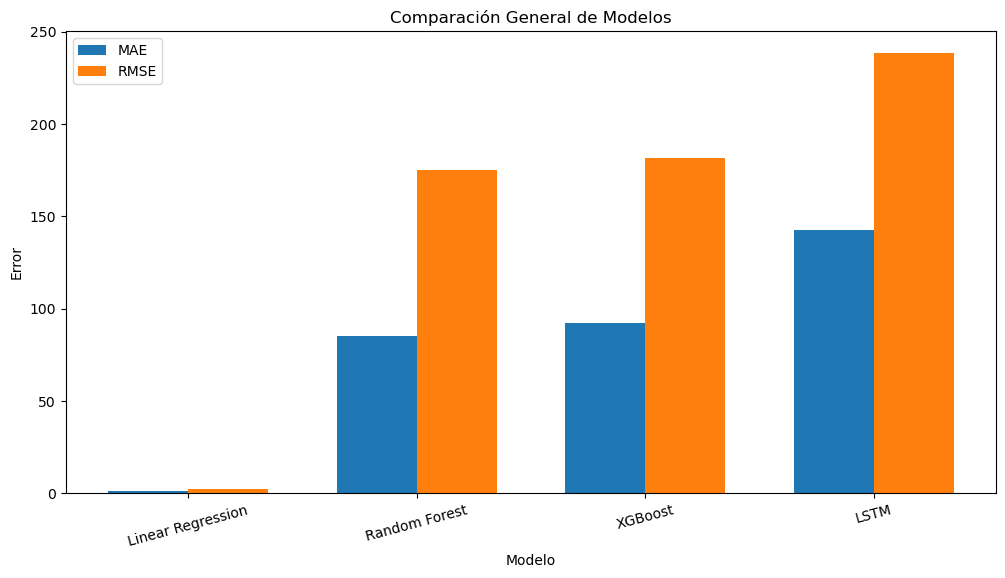

In [128]:
# Visualizacion combinada
x = np.arange(len(results['Modelo']))
width = 0.35

fig, ax = plt.subplots(figsize=(12,6))

ax.bar(
    x - width/2,
    results['MAE'],
    width,
    label='MAE'
)

ax.bar(
    x + width/2,
    results['RMSE'],
    width,
    label='RMSE'
)

ax.set_title('Comparación General de Modelos')
ax.set_xlabel('Modelo')
ax.set_ylabel('Error')

ax.set_xticks(x)
ax.set_xticklabels(results['Modelo'])

ax.legend()

plt.xticks(rotation=15)

plt.show()